# 0DTE nearest-OTM call + put, 15:30 → 16:00

One trade per expiration day. At 15:30 ET, "ATM" means the **nearest
out-of-the-money** legs:

- call: smallest listed $K_c \ge S$ with a live mid
- put: largest listed $K_p \le S$ with a live mid

If $S$ sits on a strike those are the same $K$ (a straddle); otherwise it is
a one-strike-wide strangle. Cash settlement uses the official S&P 500 close
from yfinance (`^GSPC`): call $\max(S_{\mathrm{close}}-K_c,0)$, put
$\max(K_p-S_{\mathrm{close}},0)$.

Signal is remaining RV minus remaining IV in variance space:
$s=\widehat{RV}-(\mathrm{IV}_{\mathrm{hourly}}/\sqrt{2})^2$, with
$\widehat{RV}=(m^2+\hat\sigma^2)B$ the causal second-order map from
`yhat`. The book that survives the variants below is **always short**.
Long-short volatility $\pm 1$ is a control. Vol-space maps ($\hat y\sqrt{B}$, $m\sqrt{B}$) live in
`atm_straddle_volmap.ipynb` if present, else
`atm_straddle_experimental.ipynb`. Ensembles / extra weights:
`atm_straddle_experimental.ipynb`. $R\sim a+b s$ is below with the
signal. Every-bar 30-min book: `atm_straddle_intraday.ipynb`.

Every cell reads from `data/` (or from a frame the previous cell just built).
Print the table before using it.

In [1]:
import hashlib
import os
from pathlib import Path
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import yfinance as yf
import statsmodels.api as sm

def find_repo(start: Path) -> Path:
    for q in [start.resolve(), *start.resolve().parents]:
        if (q / "data" / "spxw_chain.parquet").exists():
            return q
    raise FileNotFoundError("repo root not found")

REPO = find_repo(Path.cwd())
OUT = REPO / "results" / "atm_straddle_0dte_1530"
OUT.mkdir(parents=True, exist_ok=True)
# derived-input cache: every entry is keyed on the source file's
# size+mtime (and the request), so a changed input can never serve a
# stale hit. Delete the directory to force a cold rebuild.
CACHE = OUT / "cache"
CACHE.mkdir(parents=True, exist_ok=True)
print("repo:", REPO)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 24)
pd.set_option("display.float_format", lambda x: f"{x: .6f}")


repo: C:\Users\james\CC Allowed\harxhar-0dte-professor


## 1. Load the chain (15:30 and 16:00 ET only)

File: `data/spxw_chain.parquet`. The file has every 30-minute stamp; this
strategy needs 15:30 (entry quotes). 16:00 chain stamps are kept only to
compare the tape underlying against the official close. First read
`timestamp` and keep those two Eastern clocks; then load the remaining
columns for those stamps only.

In [2]:
path = REPO / "data" / "spxw_chain.parquet"
COLS = [
    "expiration",
    "timestamp",
    "strike",
    "cp",
    "bid",
    "ask",
    "mid",
    "underlying_price",
    "impl_volatility",
]
_st = os.stat(path)
_ck = CACHE / f"chain_15301600_{_st.st_size}_{_st.st_mtime_ns}.parquet"
if _ck.exists():
    chain = pd.read_parquet(_ck)
    print(f"cache hit {_ck.name} (source size+mtime matched; "
          "full-file stamp scan skipped)")
else:
    ts = pd.to_datetime(pd.read_parquet(path, columns=["timestamp"])["timestamp"], utc=True)
    et = ts.dt.tz_convert("America/New_York")
    keep = ts[
        ((et.dt.hour == 15) & (et.dt.minute == 30)) | ((et.dt.hour == 16) & (et.dt.minute == 0))
    ].unique()
    print("unique timestamps in file", ts.nunique())
    print("15:30/16:00 ET stamps kept", len(keep))
    del ts, et
    chain = pd.read_parquet(path, columns=COLS, filters=[("timestamp", "in", list(keep))])
    chain["timestamp"] = pd.to_datetime(chain["timestamp"], utc=True)
    chain["expiration"] = pd.to_datetime(chain["expiration"])
    chain["cp"] = chain["cp"].astype(str).str.upper().str[0]
    for _old in CACHE.glob("chain_15301600_*.parquet"):
        _old.unlink()
    chain.to_parquet(_ck)
print("rows", f"{len(chain):,}")
print("columns", list(chain.columns))
print("timestamp", chain["timestamp"].min(), "->", chain["timestamp"].max())
print("expirations", chain["expiration"].nunique())
print(chain.head(3))


cache hit chain_15301600_77439812_1786671584951439500.parquet (source size+mtime matched; full-file stamp scan skipped)
rows 1,171,254
columns ['expiration', 'timestamp', 'strike', 'cp', 'bid', 'ask', 'mid', 'underlying_price', 'impl_volatility']
timestamp 2020-01-03 20:30:00+00:00 -> 2025-12-31 21:00:00+00:00
expirations 1291
  expiration                 timestamp       strike cp         bid         ask         mid  underlying_price  impl_volatility
0 2020-01-03 2020-01-03 20:30:00+00:00  2665.000000  C  571.599976  575.299988  573.450012       3238.300049         0.025000
1 2020-01-03 2020-01-03 21:00:00+00:00  2665.000000  C  559.799988  581.900024  570.849976       3234.350098         0.025000
2 2020-01-03 2020-01-03 20:30:00+00:00  2665.000000  P    0.000000    0.050000    0.025000       3238.300049         0.025000


## 2. Clocks and 0DTE flag

Vendor stamps are UTC. Session clock is America/New_York. A row is 0DTE when the
ET calendar date of the stamp equals the expiration date.

In [3]:
# ~3M rows share ~4k unique stamps: convert clocks once per unique
# value and take() back, instead of per-row strftime/tz work.
codes, uts = pd.factorize(chain["timestamp"])
assert (codes >= 0).all(), "null timestamp in chain"
uet = pd.DatetimeIndex(uts).tz_convert("America/New_York")
chain["et"] = uet.take(codes)
hh = np.where(
    (uet.hour == 15) & (uet.minute == 30), "15:30",
    np.where((uet.hour == 16) & (uet.minute == 0), "16:00", "other"),
)
chain["hhmm"] = hh[codes]
chain["et_date"] = uet.normalize().take(codes)
ecodes, uexp = pd.factorize(chain["expiration"])
assert (ecodes >= 0).all(), "null expiration in chain"
uexp_d = (
    pd.DatetimeIndex(uexp)
    .tz_localize("America/New_York", ambiguous="NaT", nonexistent="NaT")
    .normalize()
)
chain["exp_date"] = uexp_d.take(ecodes)
chain["is_0dte"] = chain["et_date"] == chain["exp_date"]
print("0DTE rows", f"{int(chain['is_0dte'].sum()):,}", "/", f"{len(chain):,}")
print("ET hour counts on 0DTE:")
print(chain.loc[chain["is_0dte"], "et"].dt.hour.value_counts().sort_index().to_string())
print("15:30 0DTE stamps", chain.loc[chain["is_0dte"] & (chain["hhmm"] == "15:30"), "timestamp"].nunique())
print("16:00 0DTE stamps", chain.loc[chain["is_0dte"] & (chain["hhmm"] == "16:00"), "timestamp"].nunique())


0DTE rows 1,171,254 / 1,171,254
ET hour counts on 0DTE:
et
15    585627
16    585627


15:30 0DTE stamps 1291
16:00 0DTE stamps 1291


## 3. Restrict to 0DTE rows at those two clocks

15:30 is the entry quote. 16:00 chain rows are only for a tape-vs-close
check; settlement spot is yfinance `^GSPC`. The chain load already dropped
other hours; this drops any non-expiration-day leftovers.

In [4]:
book_chain = chain[chain["is_0dte"] & chain["hhmm"].isin(["15:30", "16:00"])].copy()
print("rows", f"{len(book_chain):,}")
print(book_chain.groupby("hhmm").agg(rows=("strike", "size"), days=("expiration", "nunique"), stamps=("timestamp", "nunique")))
print(book_chain.head(3))
del chain


rows 1,171,254


         rows  days  stamps
hhmm                       
15:30  585627  1291    1291
16:00  585627  1291    1291
  expiration                 timestamp       strike cp         bid         ask         mid  underlying_price  impl_volatility                        et  \
0 2020-01-03 2020-01-03 20:30:00+00:00  2665.000000  C  571.599976  575.299988  573.450012       3238.300049         0.025000 2020-01-03 15:30:00-05:00   
1 2020-01-03 2020-01-03 21:00:00+00:00  2665.000000  C  559.799988  581.900024  570.849976       3234.350098         0.025000 2020-01-03 16:00:00-05:00   
2 2020-01-03 2020-01-03 20:30:00+00:00  2665.000000  P    0.000000    0.050000    0.025000       3238.300049         0.025000 2020-01-03 15:30:00-05:00   

    hhmm                   et_date                  exp_date  is_0dte  
0  15:30 2020-01-03 00:00:00-05:00 2020-01-03 00:00:00-05:00     True  
1  16:00 2020-01-03 00:00:00-05:00 2020-01-03 00:00:00-05:00     True  
2  15:30 2020-01-03 00:00:00-05:00 2020-01-03 00:00

## 4. Nearest OTM call and put at 15:30

Spot $S$ from the 15:30 print. Among quotes with a finite mid $> 0$:

- call: smallest $K_c \ge S$
- put: largest $K_p \le S$

Print how many days lose a leg. Entry $= \mathrm{mid}(K_c) + \mathrm{mid}(K_p)$.

In [5]:
e = book_chain[book_chain["hhmm"] == "15:30"].copy()
n_days = e["expiration"].nunique()
live = e[np.isfinite(e["mid"]) & (e["mid"] > 0)].copy()
live["S"] = live["underlying_price"].astype(float)
spot = live.dropna(subset=["S"]).groupby("expiration")["S"].first()
print("15:30 0DTE days", n_days, "with a spot", int(spot.notna().sum()))
print("15:30 0DTE rows", f"{len(e):,}", "with finite mid>0", f"{len(live):,}",
      f"({len(live) / max(len(e), 1):.1%} of rows)")

c = live[live["cp"] == "C"].copy()
p = live[live["cp"] == "P"].copy()
c["S"] = c["expiration"].map(spot)
p["S"] = p["expiration"].map(spot)
c = c[np.isfinite(c["S"])]
p = p[np.isfinite(p["S"])]

c_otm = c[c["strike"] >= c["S"]].copy()
c_otm["k_gap"] = c_otm["strike"].astype(float) - c_otm["S"]
c_pick = (
    c_otm.sort_values(["expiration", "k_gap", "strike"])
    .groupby("expiration", as_index=False)
    .first()
)
p_otm = p[p["strike"] <= p["S"]].copy()
p_otm["k_gap"] = p_otm["S"] - p_otm["strike"].astype(float)
p_pick = (
    p_otm.sort_values(["expiration", "k_gap", "strike"])
    .groupby("expiration", as_index=False)
    .first()
)
print("days with a nearest-OTM call (K>=S, live mid)", len(c_pick))
print("days with a nearest-OTM put  (K<=S, live mid)", len(p_pick))
print("days missing OTM call", n_days - len(c_pick), "missing OTM put", n_days - len(p_pick))

atm = c_pick.merge(p_pick, on="expiration", suffixes=("_c", "_p"))
atm["S"] = atm["S_c"].astype(float)
atm["K_c"] = atm["strike_c"].astype(float)
atm["K_p"] = atm["strike_p"].astype(float)
atm["entry"] = atm["mid_c"].astype(float) + atm["mid_p"].astype(float)
atm["day"] = atm["et_c"].dt.tz_convert("America/New_York").dt.normalize().dt.tz_localize(None)
atm["same_strike"] = atm["K_c"] == atm["K_p"]
print("days with both legs", len(atm), "dropped", n_days - len(atm))
print("frac same strike (spot on a listed K)", float(atm["same_strike"].mean()))
print("median K_c - S", float((atm["K_c"] - atm["S"]).median()),
      "median S - K_p", float((atm["S"] - atm["K_p"]).median()))
print(atm[["expiration", "S", "K_c", "K_p", "mid_c", "mid_p", "entry", "same_strike"]].head(8))
print("---")
print(atm[["S", "K_c", "K_p", "entry"]].describe())


15:30 0DTE days 1291 with a spot 1291
15:30 0DTE rows 585,627 with finite mid>0 585,532 (100.0% of rows)


days with a nearest-OTM call (K>=S, live mid) 1291
days with a nearest-OTM put  (K<=S, live mid) 1291
days missing OTM call 0 missing OTM put 0
days with both legs 1291 dropped 0
frac same strike (spot on a listed K) 0.000774593338497289
median K_c - S 2.5400390625 median S - K_p 2.4599609375
  expiration            S          K_c          K_p     mid_c     mid_p     entry  same_strike
0 2020-01-03  3238.300049  3240.000000  3235.000000  1.300000  1.250000  2.550000        False
1 2020-01-06  3240.540039  3245.000000  3240.000000  0.200000  1.450000  1.650000        False
2 2020-01-08  3266.530029  3270.000000  3265.000000  0.525000  1.000000  1.525000        False
3 2020-01-10  3267.570068  3270.000000  3265.000000  1.150000  1.300000  2.450000        False
4 2020-01-13  3282.340088  3285.000000  3280.000000  0.550000  0.675000  1.225000        False
5 2020-01-15  3284.679932  3285.000000  3280.000000  1.950000  0.675000  2.625000        False
6 2020-01-17  3324.280029  3325.000000  3

## 5. Exit = cash settlement at the official close

Each leg cash-settles at intrinsic vs the official S&P 500 close
(`^GSPC` from yfinance), not a 16:00 option quote:

- call: $\max(S_{\mathrm{close}}-K_c, 0)$
- put: $\max(K_p-S_{\mathrm{close}}, 0)$

If the close stays between $K_p$ and $K_c$, both finish OTM and settlement is 0.
Print the gap vs the 16:00 chain underlying as a check.

In [6]:
def load_gspc_close(days: pd.Series) -> pd.Series:
    days = pd.to_datetime(days)
    start = pd.Timestamp(days.min()) - pd.Timedelta("7D")
    end = pd.Timestamp(days.max()) + pd.Timedelta("7D")
    cp = CACHE / "gspc_close.parquet"
    if cp.exists():
        cached = pd.read_parquet(cp)["close"]
        cached.index = pd.to_datetime(cached.index)
        if cached.index.min() <= pd.Timestamp(days.min()) and cached.index.max() >= pd.Timestamp(days.max()):
            print(f"cache hit {cp.name} (covers {cached.index.min().date()} .. {cached.index.max().date()})")
            return cached.astype(float)
    raw = yf.download("^GSPC", start=start, end=end, auto_adjust=True, progress=False, threads=True)
    close = raw["Close"]
    if isinstance(close, pd.DataFrame):
        close = close.iloc[:, 0]
    ix = pd.to_datetime(close.index)
    if getattr(ix, "tz", None) is not None:
        ix = ix.tz_convert("America/New_York").tz_localize(None)
    close.index = ix.normalize()
    close = close.astype(float)
    close.rename("close").to_frame().to_parquet(cp)
    return close


atm = atm.reset_index(drop=True)
exp_day = pd.to_datetime(atm["expiration"])
if getattr(exp_day.dt, "tz", None) is not None:
    exp_day = exp_day.dt.tz_convert("America/New_York").dt.tz_localize(None)
exp_day = exp_day.dt.normalize()
atm["S_close"] = exp_day.map(load_gspc_close(exp_day))

x = book_chain[book_chain["hhmm"] == "16:00"]
s_tape = (
    x.dropna(subset=["underlying_price"])
    .groupby("expiration")["underlying_price"]
    .first()
)
atm["S_1600_tape"] = atm["expiration"].map(s_tape).astype(float)
gap = (atm["S_close"] - atm["S_1600_tape"]).abs()
print("yfinance ^GSPC close vs 16:00 chain underlying")
print(pd.DataFrame({
    "S_close": atm["S_close"],
    "S_1600_tape": atm["S_1600_tape"],
    "abs_gap": gap,
}).describe())
print("days missing yfinance close", int(atm["S_close"].isna().sum()))
print("median |close - tape|", float(gap.median()) if gap.notna().any() else float("nan"))

atm["pay_c"] = np.maximum(atm["S_close"] - atm["K_c"], 0.0)
atm["pay_p"] = np.maximum(atm["K_p"] - atm["S_close"], 0.0)
atm["exit"] = atm["pay_c"] + atm["pay_p"]
print(atm[["expiration", "S", "K_c", "K_p", "S_close", "S_1600_tape", "pay_c", "pay_p", "entry", "exit"]].head(8))
print("frac settlement 0 (close between K_p and K_c)", float((atm["exit"] == 0).mean()))
atm = atm[np.isfinite(atm["entry"]) & np.isfinite(atm["exit"]) & (atm["entry"] > 0)].copy()


cache hit gspc_close.parquet (covers 2019-12-27 .. 2026-01-06)


yfinance ^GSPC close vs 16:00 chain underlying
           S_close  S_1600_tape      abs_gap
count  1291.000000  1291.000000  1291.000000
mean   4708.704570  4708.780010     0.534863
std    1031.543891  1031.522314     0.574065
min    2237.399902  2236.300049     0.000000
25%    3971.940063  3971.824951     0.160156
50%    4455.479980  4455.560059     0.379883
75%    5572.459961  5572.514893     0.709961
max    6932.049805  6932.049805     5.909912
days missing yfinance close 0
median |close - tape| 0.3798828125
  expiration            S          K_c          K_p      S_close  S_1600_tape     pay_c      pay_p     entry       exit
0 2020-01-03  3238.300049  3240.000000  3235.000000  3234.850098  3234.350098  0.000000   0.149902  2.550000   0.149902
1 2020-01-06  3240.540039  3245.000000  3240.000000  3246.280029  3246.229980  1.280029   0.000000  1.650000   1.280029
2 2020-01-08  3266.530029  3270.000000  3265.000000  3253.050049  3253.209961  0.000000  11.949951  1.525000  11.949951
3 2

## 6. Return $R = \mathrm{exit}/P_{15:30} - 1$

Paid `entry` at 15:30; received `pay_c + pay_p` in cash at the close.

In [7]:
atm["R"] = atm["exit"] / atm["entry"] - 1.0
atm = atm.set_index("day").sort_index()
print(atm[["expiration", "K_c", "K_p", "entry", "exit", "R"]].head(8))
print("---")
print(atm["R"].describe())
print("n", len(atm))


           expiration          K_c          K_p     entry       exit         R
day                                                                           
2020-01-03 2020-01-03  3240.000000  3235.000000  2.550000   0.149902 -0.941215
2020-01-06 2020-01-06  3245.000000  3240.000000  1.650000   1.280029 -0.224225
2020-01-08 2020-01-08  3270.000000  3265.000000  1.525000  11.949951  6.836034
2020-01-10 2020-01-10  3270.000000  3265.000000  2.450000   0.000000 -1.000000
2020-01-13 2020-01-13  3285.000000  3280.000000  1.225000   3.129883  1.555006
2020-01-15 2020-01-15  3285.000000  3280.000000  2.625000   4.290039  0.634301
2020-01-17 2020-01-17  3325.000000  3320.000000  2.325000   4.620117  0.987147
2020-01-21 2020-01-21  3325.000000  3320.000000  1.550000   0.000000 -1.000000
---
count    1291.000000
mean       -0.033629
std         1.124668
min        -1.000000
25%        -0.947002
50%        -0.335511
75%         0.400174
max        10.316049
Name: R, dtype: float64
n 1291


## 7. Variance forecasts

Six models, one parquet each (all dumped by
`experiments/dump_unif_yhat.py` from the CARC unification chunks,
post-2026-08-17 ET→UTC clock fix):

- `yhat_a0.parquet` — HAR + calendar OLS (`a0_ols_har`)
- `yhat_blk2_fomc1.parquet` — two-block ridge with FOMC in X
  (`blk2_user` on the `fomc1` panel)
- `yhat_tree00.parquet` — LGBM on the wide all-features design
  (`tree_expert_00`, frozen tree-expert menu)
- `yhat_tree16.parquet` — XGB on the wide all-features design
  (`tree_expert_16`, frozen tree-expert menu)
- `yhat_b2lasso_tuned.parquet` — causal-tuned lasso on the same
  all-features design (`b2_lasso_tuned`, the paper-protocol lasso)
- `yhat_b2lasso.parquet` — fixed $\alpha=10^{-4}$ lasso
  (`b2_lasso`, hand-pinned $\alpha$; envelope center, not the
  paper head-to-head)

Stored `yhat` is on the fit scale
$y=\sqrt{RV/B}$ (winsorized). Map back to raw 30-minute variance with
the causal second-order correction: on days $[t-250,t)$ fit
$m=a+b\,\hat y$ and residual $\hat\sigma^2$ against unwinsorized
$y^{\mathrm{raw}}=\sqrt{RV^{\mathrm{raw}}/B}$, then
$\mathrm{rv\_hat}=(m^2+\hat\sigma^2)B$. That is $E[RV]$ for the
15:30–16:00 bar. All models load in parallel.

**Fit set and alignment.** Panel stamps are **bar-end labelled**: the
row at stamp $\tau$ carries the realized variance of $[\tau-30,\tau]$
and the forecast of that bar, issued at $\tau-30$. The 15:30 book
therefore reads the **stamp-16:00 row** — the forecast issued at
15:30 for the 15:30$\to$close bar it trades; earlier versions read
the stamp-15:30 row, which is the forecast of 15:00$\to$15:30:
causal but one bar stale. The MZ regression fits only the scored
session bars (stamps 10:30–16:00, i.e. bars 10:00–16:00);
off-session bars are mispredicted by $\sim$50–100$\times$ and
previously polluted the calibration (mean $\mathrm{rv\_hat}/RV$
1.14 $\to$ 1.08 after the restriction). Coefficients still apply to
every row.

Mechanics (wall clock only): the 2-parameter fit is solved in closed
form from day-level **prefix sums**; the machinery lives in
`atm_straddle_lib.second_order_raw` (shared with the intraday
notebook); each model's 15:30 table is cached under
`results/atm_straddle_0dte_1530/cache/`, keyed on the source
parquet's size+mtime, the fit-set/window version, and the option-day
set, so a re-run with unchanged inputs skips the whole computation.

In [8]:
from concurrent.futures import ThreadPoolExecutor

YHATS = {
    "a0": REPO / "results" / "spxw_pnl" / "yhat_a0.parquet",
    "blk2": REPO / "results" / "spxw_pnl" / "yhat_blk2_fomc1.parquet",
    "lgbm": REPO / "results" / "spxw_pnl" / "yhat_tree00.parquet",
    "xgb": REPO / "results" / "spxw_pnl" / "yhat_tree16.parquet",
    "lasso_t": REPO / "results" / "spxw_pnl" / "yhat_b2lasso_tuned.parquet",
    "lasso_f": REPO / "results" / "spxw_pnl" / "yhat_b2lasso.parquet",
    "enet": REPO / "results" / "spxw_pnl" / "yhat_b3enet_tuned.parquet",
}
# The second-order map (MZ smear) lives in atm_straddle_lib: flat
# 250-day window, fit restricted to the scored session bars
# (10:00-15:30 ET) so off-session dynamics cannot pollute the
# calibration. Delegate rather than duplicate.
import sys
sys.path.insert(0, str(REPO / "notebooks"))
import atm_straddle_lib as asl

second_order_raw = asl.second_order_raw
load_yhat_1530 = asl.load_yhat_1530


def load_yhat_1530_cached(tag: str, path: Path, need_dates) -> pd.DataFrame:
    h = hashlib.sha1()
    st = os.stat(path)
    h.update(f"v6-vec-gls:{st.st_size}:{st.st_mtime_ns}:flat{asl.WINDOW_DAYS}".encode())
    for d in sorted(need_dates):
        h.update(str(d).encode())
    cp = CACHE / f"yhat1530_{tag}_{h.hexdigest()[:16]}.parquet"
    if cp.exists():
        return pd.read_parquet(cp)
    out = load_yhat_1530(path, need_dates)
    for old in CACHE.glob(f"yhat1530_{tag}_*.parquet"):
        old.unlink()
    out.to_parquet(cp)
    return out


need_dates = set(atm.index)
with ThreadPoolExecutor(max_workers=len(YHATS)) as pool:
    futs = {
        tag: pool.submit(load_yhat_1530_cached, tag, path, need_dates)
        for tag, path in YHATS.items()
    }
    models = {tag: futs[tag].result() for tag in YHATS}

LABEL = {
    "a0": "HAR + calendar OLS",
    "blk2": "block-diag ridge",
    "lgbm": "LightGBM",
    "xgb": "XGBoost",
    "lasso_t": "lasso (causally tuned)",
    "lasso_f": "lasso (fixed 1e-4)",
    "enet": "elastic net (causally tuned)",
}
print("option days", len(atm), pd.Timestamp(atm.index.min()), "->", pd.Timestamp(atm.index.max()))
for tag, rv in models.items():
    n_ov = atm.index.intersection(rv.index).nunique()
    print(f"{LABEL[tag]}: 15:30 days {len(rv)}  {pd.Timestamp(rv.index.min())} -> {pd.Timestamp(rv.index.max())}  "
          f"days in both {n_ov}  option days with no forecast {len(atm) - n_ov}")
    print(rv.head(3)[["yhat", "baseline", "rv_hat", "rv_raw"]])
    print("median rv_hat", float(rv["rv_hat"].median()),
          "median rv_raw", float(rv["rv_raw"].median()))
    print("---")


option days 1291 2020-01-03 00:00:00 -> 2025-12-31 00:00:00


HAR + calendar OLS: 15:30 days 871  2020-01-03 00:00:00 -> 2024-04-30 00:00:00  days in both 871  option days with no forecast 420
                yhat  baseline    rv_hat    rv_raw
date                                              
2020-01-03  1.543206  0.000001  0.000004  0.000004
2020-01-06  1.012508  0.000001  0.000002  0.000001
2020-01-08  1.158877  0.000001  0.000002  0.000004
median rv_hat 4.498853487981324e-06 median rv_raw 4.233099274555844e-06
---
block-diag ridge: 15:30 days 871  2020-01-03 00:00:00 -> 2024-04-30 00:00:00  days in both 871  option days with no forecast 420
                yhat  baseline    rv_hat    rv_raw
date                                              
2020-01-03  1.764510  0.000001  0.000004  0.000004
2020-01-06  1.073883  0.000001  0.000002  0.000001
2020-01-08  1.111637  0.000001  0.000002  0.000004
median rv_hat 4.788166332870916e-06 median rv_raw 4.233099274555844e-06
---
LightGBM: 15:30 days 871  2020-01-03 00:00:00 -> 2024-04-30 00:00:00  days in 

## 8. Put IV in the same space as RV

The chain column is `impl_volatility` (export name `new_implied_vol`).
OM's manual says **annualized** BS vol (ATM $\sim 0.20$). The tape is
$\sim 0.002$ at ATM — $\sim 100\times$ too small. Mids still price
$\sim 20\%$ vol. That is the unit tell: the number behaves as a
**1-hour SD**, not as OM annualized vol.

$$
\mathrm{Var}(1\mathrm{h})\approx 0.002^{2}=4\times 10^{-6},\qquad
\mathrm{IV}_{30}=\mathrm{IV}_{\mathrm{hourly}}/\sqrt{2},\qquad
\mathrm{iv\_var}=\mathrm{IV}_{30}^{2}=(\mathrm{IV}_{\mathrm{hourly}})^{2}/2.
$$

That $10^{-6}$ variance is the same scale as $\widehat{RV}$. Treating
$0.002$ as annualized and dividing by $252\times 6.5$ lands at
$\sim 10^{-9}$ and cannot be compared to $\widehat{RV}$. No BS inversion
from the mid. Remaining window here is 30 min, so this is also
remaining-session variance.

In [9]:
atm["iv_c"] = pd.to_numeric(atm["impl_volatility_c"], errors="coerce")
atm["iv_p"] = pd.to_numeric(atm["impl_volatility_p"], errors="coerce")
atm["iv_hourly"] = atm[["iv_c", "iv_p"]].mean(axis=1)
atm["iv_30"] = atm["iv_hourly"] / np.sqrt(2.0)
atm["iv_var"] = atm["iv_30"] ** 2
print(atm[["S", "K_c", "K_p", "entry", "iv_hourly", "iv_30", "iv_var"]].head(8))
print("---")
print(atm[["iv_hourly", "iv_30", "iv_var"]].describe())
print("days missing quoted IV", int(atm["iv_hourly"].isna().sum()))


                      S          K_c          K_p     entry  iv_hourly     iv_30    iv_var
day                                                                                       
2020-01-03  3238.300049  3240.000000  3235.000000  2.550000   0.002523  0.001784  0.000003
2020-01-06  3240.540039  3245.000000  3240.000000  1.650000   0.001734  0.001226  0.000002
2020-01-08  3266.530029  3270.000000  3265.000000  1.525000   0.001839  0.001300  0.000002
2020-01-10  3267.570068  3270.000000  3265.000000  2.450000   0.002450  0.001732  0.000003
2020-01-13  3282.340088  3285.000000  3280.000000  1.225000   0.001675  0.001184  0.000001
2020-01-15  3284.679932  3285.000000  3280.000000  2.625000   0.002376  0.001680  0.000003
2020-01-17  3324.280029  3325.000000  3320.000000  2.325000   0.002223  0.001572  0.000002
2020-01-21  3323.949951  3325.000000  3320.000000  1.550000   0.001805  0.001276  0.000002
---
         iv_hourly        iv_30       iv_var
count  1291.000000  1291.000000  1291.000

## 9. Signal and long-short volatility position

Variance space: $s=\mathrm{rv\_hat}-(\mathrm{IV}/\sqrt{2})^2$.
$\mathrm{pos}=+1$ if $s>0$, else $-1$. Portfolio return is
$\mathrm{pos}\cdot R$.

In [10]:
def make_book(rv: pd.DataFrame) -> tuple[pd.DataFrame, pd.Series]:
    px = atm.join(rv[["rv_hat"]], how="inner")
    px = px.dropna(subset=["R", "rv_hat", "iv_var", "entry"])
    px = px[(px["rv_hat"] > 0) & (px["iv_var"] > 0)]
    px["signal"] = px["rv_hat"] - px["iv_var"]
    px["pos"] = np.where(px["signal"] > 0, 1.0, -1.0)
    px["R_p"] = px["pos"] * px["R"]
    mu = float(px["R_p"].mean())
    sd = float(px["R_p"].std())
    r_short = -px["R"]
    stats = pd.Series({
        "n_days": len(px),
        "frac_long": float((px["pos"] > 0).mean()),
        "frac_short": float((px["pos"] < 0).mean()),
        "mean_Rp": mu,
        "Sharpe_ann": mu / sd * np.sqrt(252.0) if sd > 0 else float("nan"),
        "mean_Rp always-short": float(r_short.mean()),
        "Sharpe_ann always-short": float(r_short.mean() / r_short.std() * np.sqrt(252)),
        "start": pd.Timestamp(px.index.min()),
        "end": pd.Timestamp(px.index.max()),
    })
    return px, stats

books, stat_cols = {}, {}
for tag, rv in models.items():
    px, st = make_book(rv)
    books[tag] = px
    stat_cols[tag] = st
    px.to_parquet(OUT / f"daily_{tag}.parquet")
    print("wrote", OUT / f"daily_{tag}.parquet")

print(pd.DataFrame(stat_cols).rename(columns=LABEL).to_string())
print("---")
print("hand-check HAR+calendar (R_p = R if pos==1, else -R):")
print(books["a0"][["entry", "exit", "R", "rv_hat", "iv_hourly", "iv_30", "iv_var", "signal", "pos", "R_p"]].head(8))


wrote C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530\daily_a0.parquet
wrote C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530\daily_blk2.parquet


wrote C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530\daily_lgbm.parquet
wrote C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530\daily_xgb.parquet


wrote C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530\daily_lasso_t.parquet
wrote C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530\daily_lasso_f.parquet


wrote C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530\daily_enet.parquet
                          HAR + calendar OLS     block-diag ridge             LightGBM              XGBoost lasso (causally tuned)   lasso (fixed 1e-4) elastic net (causally tuned)
n_days                                   871                  871                  871                  871                    871                  871                          871
frac_long                           0.321470             0.389208             0.323766             0.315729               0.367394             0.419059                     0.347876
frac_short                          0.678530             0.610792             0.676234             0.684271               0.632606             0.580941                     0.652124
mean_Rp                             0.070631             0.115210             0.094258             0.098188               0.102058             0.129840                    

## 10. Rule table — grouped by strategy

Same days and the same long-straddle $R$ (15:30 mid to cash settlement).
Only the position $q_t$ changes. One block per rule; **rows are the seven
forecast models**, scored on the intersection of all model books. Mid
fill. The always-short rule takes no forecast — every model row is
identical — so it is shown as a single anonymous row.

**Rules** (each returns $R'_t = q_t R_t$):

- **always short:** $q_t=-1$ every day. No forecast.
- **long-short volatility:** $q_t=\mathrm{sign}(s_t)$, with
  $s_t=\widehat{RV}_t-\mathrm{IV}_{30,t}^{2}$. Long the package when the
  forecast exceeds implied variance, short otherwise.

Columns are `Series.describe()` plus skew, excess kurtosis, the $t$-stat of the
mean $t=\sqrt{n}\cdot\mathrm{mean}/\mathrm{std}$, and buy-signal
count / percent (days with $q_t>0$). $t$ uses the raw
mean/std, not annualized Sharpe.

`ex_kurt` is **excess** kurtosis (Fisher's definition, what pandas
`Series.kurt()` returns): the fourth standardized moment minus 3, so
the Gaussian benchmark scores 0 rather than 3. Positive values mean
fatter tails than a normal with the same variance; raw (Pearson)
kurtosis is `ex_kurt + 3`.

`Sharpe_ann` is the **annualized** Sharpe ratio,
$\mathrm{mean}/\mathrm{std}\times\sqrt{252}$ on the daily $R'$; every
other moment column is daily and unannualized. $t$ and Sharpe carry
the same information at fixed $n$
($t=\mathrm{Sharpe}\times\sqrt{n/252}$); both are shown so the table
reads either way.

Only the scored days are restricted to the common set.

days per model: {'HAR + calendar OLS': 871, 'block-diag ridge': 871, 'LightGBM': 871, 'XGBoost': 871, 'lasso (causally tuned)': 871, 'lasso (fixed 1e-4)': 871, 'elastic net (causally tuned)': 871}
common days: 871 2020-01-03 00:00:00 -> 2024-04-30 00:00:00


always short
                     n      mean       std        min       25%       50%       75%       max      skew    ex_kurt    t_mean  Sharpe_ann     n_buy   pct_buy
all models  871.000000  0.020132  1.126834 -10.316049 -0.443536  0.328935  0.931263  1.000000 -2.314322  10.899722  0.527286    0.283620  0.000000  0.000000
---
long-short volatility
                                       n      mean       std       min       25%       50%       75%        max      skew    ex_kurt    t_mean  Sharpe_ann       n_buy    pct_buy
HAR + calendar OLS            871.000000  0.070631  1.124796 -5.422480 -0.634595  0.175593  0.883120  10.316049  0.540578  10.675141  1.853235    0.996832  280.000000  32.146958
block-diag ridge              871.000000  0.115210  1.121103 -5.422480 -0.686180  0.151136  0.912365  10.316049  0.960620  10.558120  3.032871    1.631342  339.000000  38.920781
LightGBM                      871.000000  0.094258  1.123061 -5.422480 -0.639430  0.175593  0.899516  10.316049  

saved C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530\rule_hists_blk2.png


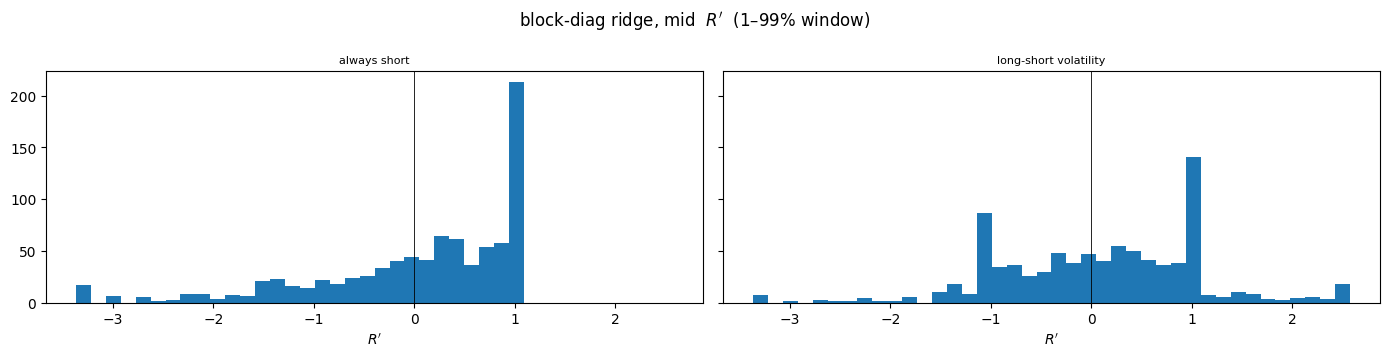

In [11]:
def rule_sizes(px: pd.DataFrame) -> dict[str, pd.Series]:
    return {
        "always short": pd.Series(-1.0, index=px.index),
        "long-short volatility": px["pos"],
    }


def rule_row(r: pd.Series, size: pd.Series) -> pd.Series:
    r = pd.Series(r).astype(float)
    size = pd.Series(size, index=r.index).astype(float)
    x = r.dropna()
    n = int(len(x))
    mu = float(x.mean())
    sd = float(x.std(ddof=1))
    n_buy = int((size > 0).sum())
    n_sz = int(size.notna().sum())
    return pd.Series({
        "n": n,
        "mean": mu,
        "std": sd,
        "min": float(x.min()),
        "25%": float(x.quantile(0.25)),
        "50%": float(x.median()),
        "75%": float(x.quantile(0.75)),
        "max": float(x.max()),
        "skew": float(x.skew()),
        "ex_kurt": float(x.kurt()),
        "t_mean": mu / sd * np.sqrt(n) if sd > 0 else float("nan"),
        "Sharpe_ann": mu / sd * np.sqrt(252.0) if sd > 0 else float("nan"),
        "n_buy": n_buy,
        "pct_buy": 100.0 * n_buy / n_sz if n_sz else float("nan"),
    })


order = [
    "always short",
    "long-short volatility",
]
cols = ["n", "mean", "std", "min", "25%", "50%", "75%", "max",
        "skew", "ex_kurt", "t_mean", "Sharpe_ann", "n_buy", "pct_buy"]
MODEL_ORDER = ["a0", "blk2", "lgbm", "xgb", "lasso_t", "lasso_f", "enet"]

common = None
for tag in MODEL_ORDER:
    idx = books[tag].index
    common = idx if common is None else common.intersection(idx)
common = common.sort_values()
print("days per model:", {LABEL[t]: len(books[t]) for t in MODEL_ORDER})
print("common days:", len(common),
      pd.Timestamp(common.min()), "->", pd.Timestamp(common.max()))

rule_tabs = {}
for tag in MODEL_ORDER:
    px = books[tag]
    sizes = rule_sizes(px)
    rule_tabs[tag] = pd.DataFrame({
        name: rule_row((sizes[name] * px["R"]).loc[common], sizes[name].loc[common])
        for name in order
    }).T[cols]
    rule_tabs[tag].to_csv(OUT / f"rule_table_{tag}.csv")

for name in order:
    if name == "always short":
        # takes no forecast: every model row is identical, so print one
        # anonymous row (and assert the identity instead of trusting it)
        base = rule_tabs[MODEL_ORDER[0]].loc[name]
        for tag in MODEL_ORDER[1:]:
            assert np.allclose(rule_tabs[tag].loc[name], base), name
        tab = pd.DataFrame({"all models": base}).T[cols]
    else:
        tab = pd.DataFrame(
            {LABEL[tag]: rule_tabs[tag].loc[name] for tag in MODEL_ORDER}
        ).T[cols]
    print(name)
    print(tab.to_string())
    print("---")
    safe = "".join(ch if ch.isalnum() else "_" for ch in name)
    tab.to_csv(OUT / f"rule_by_strategy_{safe}.csv")
print("saved per-model rule_table_*.csv and per-rule rule_by_strategy_*.csv in", OUT)

fig, axes = plt.subplots(1, len(order), figsize=(14, 3.6), sharex=True, sharey=True)
px = books["blk2"]
sizes = rule_sizes(px)
pooled = pd.concat([sizes[name] * px["R"] for name in order], axis=0).dropna()
lo, hi = float(pooled.quantile(0.01)), float(pooled.quantile(0.99))
bins = np.linspace(lo, hi, 41)
for ax, name in zip(axes.ravel(), order):
    x = (sizes[name] * px["R"]).dropna()
    ax.hist(x.clip(lo, hi), bins=bins, color="C0", edgecolor="none")
    ax.axvline(0.0, color="k", lw=0.6)
    ax.set_title(name, fontsize=8)
    ax.set_xlabel(r"$R'$")
fig.suptitle("block-diag ridge, mid  $R'$  (1–99% window)")
fig.tight_layout()
fig.savefig(OUT / "rule_hists_blk2.png", dpi=120, bbox_inches="tight")
print("saved", OUT / "rule_hists_blk2.png")
display(fig)
plt.close(fig)


## 11. P&L / return calculations (non-compounded)

Same contracts and $q$ as the rule table. All series below are
**daily arithmetic** (not $\prod(1+R')$). Mid fill is the published
book. Crossed fill: long pays the ask, short receives the bid.
Half-spread TC charges $\tfrac12(\mathrm{ask}-\mathrm{bid})$ against the
trade. Point P&L is $q(\mathrm{exit}-\mathrm{entry})$; dollars use the
SPXW $100$ multiplier. Margin-scaled return uses a CBOE-style short
straddle margin on short days and the premium on long days. The plot is
cumsum of dollars.

                 rule         variant   unit           n       mean         std          min         25%         50%         75%          max      skew    ex_kurt    t_mean  Sharpe_ann       n_buy    pct_buy
         always short   mid premium R return  871.000000   0.020132    1.126834   -10.316049   -0.443536    0.328935    0.931263     1.000000 -2.314322  10.899722  0.527286    0.283620    0.000000   0.000000
         always short    crossed fill return  869.000000  -0.016758    1.170403   -10.954858   -0.491659    0.306209    0.928938     1.000000 -2.363537  11.574814 -0.422072   -0.227288    0.000000   0.000000
         always short  half-spread TC return  871.000000  -0.016799    1.125441   -10.369484   -0.473872    0.293954    0.886394     0.988372 -2.323473  11.011118 -0.440517   -0.236948    0.000000   0.000000
         always short index-point P&L points  871.000000   0.021117    7.885921   -78.370018   -2.390039    1.724805    3.972510    21.890137 -2.602497  16.119768  0.07

saved C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530\pnl_cum_usd_blk2.png


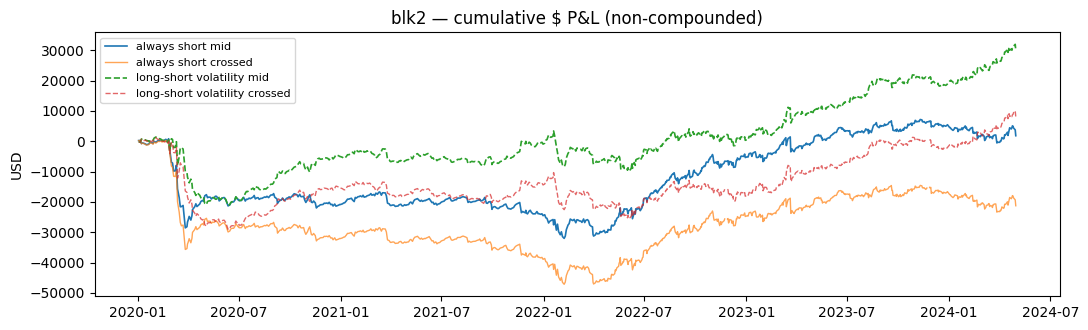

In [12]:
import sys
sys.path.insert(0, str(REPO / "notebooks"))
import atm_straddle_lib as asl

px = books["blk2"].loc[common].copy()
if "bid_entry" not in px.columns:
    px["bid_entry"] = px["bid_c"].astype(float) + px["bid_p"].astype(float)
    px["ask_entry"] = px["ask_c"].astype(float) + px["ask_p"].astype(float)
hs = 0.5 * (px["ask_entry"] - px["bid_entry"])
sizes = rule_sizes(books["blk2"])
rows = []

def add_variant(series, q, rule, variant, unit):
    st = asl.rule_row(series, q)
    rows.append({"rule": rule, "variant": variant, "unit": unit, **st.to_dict()})

for name in ("always short", "long-short volatility"):
    q = sizes[name].loc[common]
    mid = (q * px["R"])
    add_variant(mid, q, name, "mid premium R", "return")
    signq = np.sign(q.replace(0, -1.0))
    crossed = asl.crossed_premium_return(signq, px["exit"], px["bid_entry"], px["ask_entry"]) * q.abs()
    add_variant(crossed, q, name, "crossed fill", "return")
    trade = px["entry"] + signq * hs
    tc = q * (px["exit"] - trade) / px["entry"]
    add_variant(tc, q, name, "half-spread TC", "return")
    pts = asl.points_pnl(q, px["exit"], px["entry"])
    add_variant(pts, q, name, "index-point P&L", "points")
    usd = pts * asl.SPX_MULTIPLIER
    add_variant(usd, q, name, "dollar P&L", "USD")
    margin_pts = [
        asl.cboe_short_straddle_margin_points(S, Kc, Kp, ent)
        for S, Kc, Kp, ent in zip(px["S"], px["K_c"], px["K_p"], px["entry"])
    ]
    margin_pts = pd.Series(margin_pts, index=px.index)
    capital = np.where(q < 0, margin_pts * asl.SPX_MULTIPLIER, px["entry"] * asl.SPX_MULTIPLIER)
    mret = usd / np.maximum(capital, 1e-8)
    add_variant(pd.Series(mret, index=px.index), q, name, "margin-scaled", "return")

var_tab = pd.DataFrame(rows)
print(var_tab.to_string(index=False))
var_tab.to_csv(OUT / "pnl_variants_blk2.csv", index=False)

fig, ax = plt.subplots(figsize=(11, 3.4))
for name, ls in (("always short", "-"), ("long-short volatility", "--")):
    q = sizes[name].loc[common]
    ax.plot(
        px.index,
        asl.points_pnl(q, px["exit"], px["entry"]).cumsum() * asl.SPX_MULTIPLIER,
        ls, lw=1.2, label=f"{name} mid",
    )
    signq = np.sign(q.replace(0, -1.0))
    crossed_usd = (asl.crossed_premium_return(signq, px["exit"], px["bid_entry"], px["ask_entry"]) * q.abs() * px["entry"] * asl.SPX_MULTIPLIER)
    ax.plot(px.index, crossed_usd.cumsum(), ls, lw=1.0, alpha=0.7, label=f"{name} crossed")
ax.set_title("blk2 — cumulative $ P&L (non-compounded)")
ax.set_ylabel("USD")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUT / "pnl_cum_usd_blk2.png", dpi=120, bbox_inches="tight")
print("saved", OUT / "pnl_cum_usd_blk2.png")
display(fig)
plt.close(fig)


## 12. Information ratio vs always-short

Benchmark is always-short: $R^{\mathrm{AS}}_t=-R_t$ (one short package
every day). Portfolio is $R^p_t=q_t R_t$ for long-short
($q=\mathrm{sign}(s)$).

**Active return** (daily): $R^a_t=R^p_t-R^{\mathrm{AS}}_t$. On short
days $q=-1$ so $R^a=0$ (same as the bench). On buy days $q>0$ you
flipped from short to long, so $R^a=q R-(-R)=(q+1)R$ (equals $2R$
for $\pm 1$ long-short). The whole series is those daily differences
on the 871 common days.

**mean_active** $= \overline{R^a}$, the sample mean of that daily
series (not annualized).

**te_daily** (tracking error, daily) $= \mathrm{std}(R^a)$ with
$n-1$ in the denominator (`ddof=1`). **te_ann** $= \mathrm{te\_daily}\times\sqrt{252}$.

**IR_ann** $= \overline{R^a}/\mathrm{std}(R^a)\times\sqrt{252}$
$= \mathrm{mean\_active}/\mathrm{te\_ann}$. It is the Sharpe of the
*active* series, not of $R^p$.

**t_active** $= \overline{R^a}/\mathrm{std}(R^a)\times\sqrt{n}$, the
usual $t$-stat that mean active is zero. Same algebra as `t_mean` on
$R^a$. IR and $t$ move together; $t$ does not annualize.

**corr_to_bench** $= \mathrm{corr}(R^p,R^{\mathrm{AS}})$.

In [13]:
ir_rows = []
for tag in MODEL_ORDER:
    px = books[tag]
    sizes = rule_sizes(px)
    bench = (sizes["always short"] * px["R"]).loc[common]
    for name in ("long-short volatility",):
        port = (sizes[name] * px["R"]).loc[common]
        st = asl.information_ratio(port, bench)
        ir_rows.append({"model": LABEL[tag], "rule": name, **st.to_dict()})
ir_tab = (
    pd.DataFrame(ir_rows)
    .set_index(["rule", "model"])
    .sort_values(by="IR_ann", ascending=False)
    .sort_index(level="rule", sort_remaining=False)
)
print(ir_tab.to_string())
ir_tab.to_csv(OUT / "information_ratio_vs_always_short.csv")
print("IR = active return / tracking error; benchmark is always-short.")


                                                             n  mean_active  te_daily     te_ann    IR_ann  t_active  corr_to_bench
rule                  model                                                                                                        
long-short volatility lasso (fixed 1e-4)            871.000000     0.109708  1.767254  28.054288  0.985457  1.832089      -0.237873
                      block-diag ridge              871.000000     0.095078  1.670489  26.518185  0.903514  1.679746      -0.104451
                      lasso (causally tuned)        871.000000     0.081926  1.575644  25.012566  0.825399  1.534520       0.018516
                      XGBoost                       871.000000     0.078055  1.547942  24.572817  0.800474  1.488183       0.053014
                      LightGBM                      871.000000     0.074126  1.560043  24.764921  0.754281  1.402304       0.038437
                      elastic net (causally tuned)  871.000000     0.060354 

## 13. Regression of straddle returns on the signal

$R_t = a + b\,s_{t-1}$: today's package return on the **previous
expiration day's** signal. OLS with HAC lags $=6$. The question is
whether yesterday's signal carries into today's premium (day-scale
persistence); the lagged regressor is measurable strictly before
the trade by construction, so any surviving $b$ would be immune to
same-day timing concerns.

                       model           x         a            b       t_b       p_b        R2   n
          HAR + calendar OLS raw s (t-1) -0.021663 -2797.476171 -0.881521  0.378036  0.000685 870
            block-diag ridge raw s (t-1) -0.018947  -519.195857 -0.800042  0.423687  0.000118 870
                    LightGBM raw s (t-1) -0.019526  1079.269911  1.753044  0.079594  0.000594 870
                     XGBoost raw s (t-1) -0.019882  1465.815488  2.010033  0.044428  0.000966 870
      lasso (causally tuned) raw s (t-1) -0.019078   -38.901610 -0.082531  0.934225  0.000001 870
          lasso (fixed 1e-4) raw s (t-1) -0.018950  -539.927751 -0.827902  0.407726  0.000127 870
elastic net (causally tuned) raw s (t-1) -0.019067    56.707692  0.131197  0.895620  0.000002 870
reading: b tests whether yesterday's signal prices today's premium; b ~ 0 across models = no day-scale persistence.


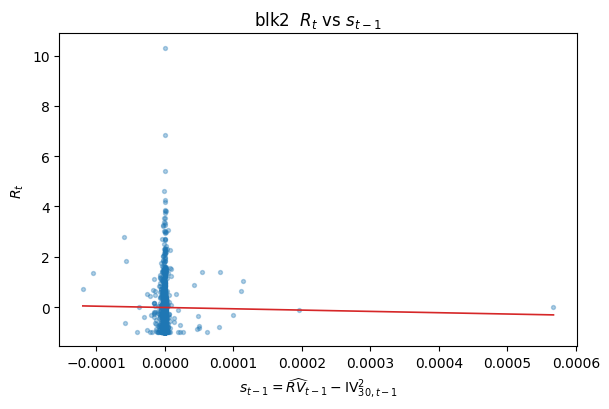

In [14]:
reg_rows = []
for tag in MODEL_ORDER:
    px = books[tag].loc[common]
    s = px["signal"].astype(float)
    r = px["R"].astype(float)
    for name, x in (("raw s (t-1)", s.shift(1)),):
        X = sm.add_constant(x.to_numpy())
        fit = sm.OLS(r.to_numpy(), X, missing="drop").fit(cov_type="HAC", cov_kwds={"maxlags": 6})
        reg_rows.append({
            "model": LABEL[tag], "x": name,
            "a": float(fit.params[0]), "b": float(fit.params[1]),
            "t_b": float(fit.tvalues[1]), "p_b": float(fit.pvalues[1]),
            "R2": float(fit.rsquared), "n": int(fit.nobs),
        })
reg_tab = pd.DataFrame(reg_rows)
print(reg_tab.to_string(index=False))
reg_tab.to_csv(OUT / "regression_R_on_signal.csv", index=False)
print("reading: b tests whether yesterday's signal prices today's premium; b ~ 0 across models = no day-scale persistence.")

px = books["blk2"].loc[common]
s_lag = px["signal"].shift(1)
ok = np.isfinite(s_lag) & np.isfinite(px["R"])
fig, ax = plt.subplots(figsize=(6.2, 4.2))
ax.scatter(s_lag[ok], px["R"][ok], s=8, alpha=0.35)
X = sm.add_constant(s_lag[ok].to_numpy())
fit = sm.OLS(px["R"][ok].to_numpy(), X).fit()
xx = np.linspace(s_lag[ok].min(), s_lag[ok].max(), 50)
ax.plot(xx, fit.params[0] + fit.params[1] * xx, color="C3", lw=1.2)
ax.set_xlabel(r"$s_{t-1}=\widehat{RV}_{t-1}-\mathrm{IV}_{30,t-1}^2$")
ax.set_ylabel(r"$R_t$")
ax.set_title("blk2  $R_t$ vs $s_{t-1}$")
fig.tight_layout()
fig.savefig(OUT / "regression_R_on_signal_blk2.png", dpi=120, bbox_inches="tight")
display(fig)
plt.close(fig)


## 14. Lagged signal, outlier-robust

The §13 OLS is leverage-dominated: $s$ is in variance units with
crash-scale tails, so a handful of extreme $s_{t-1}$ days carry most
of the fit. House rules forbid the two common fixes — no
winsorizing/clipping (the threshold is a tuned knob and clips that
bite destroy signal-carrying extremes) and no $|s|$-median scaling
(removed by decision) — so the robust checks below are all
**bounded- or parameter-free-by-construction**:

- **Rank-OLS:** regressor = the expanding percentile rank of $s$
  among days $\le t-1$ (min 63, causal), bounded $[0,1]$; OLS of
  $R_t$ on it with HAC(6). An outlier day becomes "the 99.9th
  percentile", not a 50$\sigma$ leverage point. Magnitude is
  deliberately discarded — this asks only whether any monotone
  lagged relation exists.
- **Sign split:** mean $R_t$ on $s_{t-1}>0$ vs $\le 0$ days and the
  HAC(6) $t$ of the difference — the lagged trading book's own
  economics.
- **Rank–rank association:** Spearman $\rho$ and Kendall $\tau$ of
  $(s_{t-1}, R_t)$ — both sides robust (the rank-OLS above still
  carries $R$'s $-1$ atom and tails in its residuals); parameter-free
  association tests, not causal constructions.
- **Tercile spread:** mean $R_t$ on top- vs bottom-tercile
  rank$(s_{t-1})$ days, HAC(6) $t$ — catches relations living only
  in the extremes.
- **Magnitude:** $|R_t|$ on rank$(s_{t-1})$, HAC(6) — the signal is
  a variance forecast, so even with no premium predictability it
  should predict the *size* of the next day's move. A significant
  $b$ here beside the null above is the complete statement:
  yesterday's signal prices tomorrow's risk, not tomorrow's return.

The §13 null was measured under outlier leverage; these make the
null (or any effect) trustworthy.

rank-OLS: R_t on expanding pct-rank of s_{t-1}
                       model    b_rank         t         p   n
          HAR + calendar OLS  0.167352  1.324435  0.185359 808
            block-diag ridge  0.162645  1.284966  0.198804 808
                    LightGBM  0.085736  0.702277  0.482506 808
                     XGBoost  0.107999  0.901769  0.367179 808
      lasso (causally tuned)  0.131276  1.042275  0.297284 808
          lasso (fixed 1e-4)  0.151465  1.188653  0.234576 808
elastic net (causally tuned)  0.121804  0.969793  0.332150 808
---
sign split: mean R_t by sign(s_{t-1})
                       model  mean_R|s>0  mean_R|s<=0      diff    t_diff  n_pos  n_nonpos
          HAR + calendar OLS   -0.033845    -0.012063 -0.021782 -0.268671    280       590
            block-diag ridge   -0.007201    -0.026654  0.019453  0.228341    339       531
                    LightGBM   -0.026642    -0.015463 -0.011180 -0.137570    281       589
                     XGBoost   -0.030402   

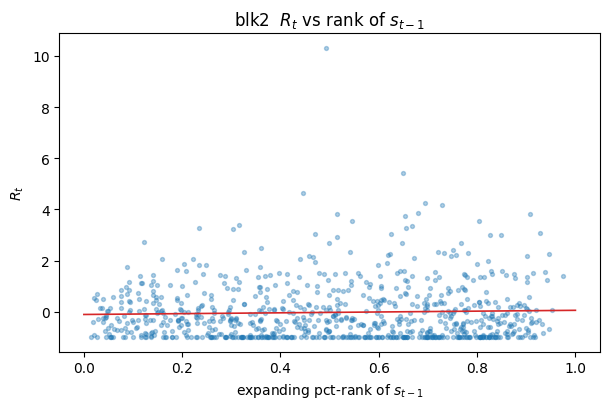

In [15]:
from scipy import stats as sps

rob_rank, rob_sign, rob_assoc, rob_terc, rob_mag = [], [], [], [], []
for tag in MODEL_ORDER:
    px = books[tag].loc[common]
    s = px["signal"].astype(float)
    r = px["R"].astype(float)
    rk = s.expanding(min_periods=63).rank(pct=True).shift(1)
    ok = np.isfinite(rk) & np.isfinite(r)
    X = sm.add_constant(rk[ok].to_numpy())
    fit = sm.OLS(r[ok].to_numpy(), X).fit(cov_type="HAC", cov_kwds={"maxlags": 6})
    rob_rank.append({"model": LABEL[tag], "b_rank": float(fit.params[1]),
                     "t": float(fit.tvalues[1]), "p": float(fit.pvalues[1]), "n": int(fit.nobs)})

    x = s.shift(1)
    ok2 = np.isfinite(x) & np.isfinite(r)
    yv = r[ok2].to_numpy()
    ind = (x[ok2] > 0).astype(float).to_numpy()
    Xs = sm.add_constant(ind)
    fs = sm.OLS(yv, Xs).fit(cov_type="HAC", cov_kwds={"maxlags": 6})
    rob_sign.append({"model": LABEL[tag],
                     "mean_R|s>0": float(yv[ind == 1].mean()),
                     "mean_R|s<=0": float(yv[ind == 0].mean()),
                     "diff": float(fs.params[1]), "t_diff": float(fs.tvalues[1]),
                     "n_pos": int(ind.sum()), "n_nonpos": int((1 - ind).sum())})

    xr = x[ok2].to_numpy()
    sp_rho, sp_p = sps.spearmanr(xr, yv)
    kt_tau, kt_p = sps.kendalltau(xr, yv)
    rob_assoc.append({"model": LABEL[tag],
                      "spearman_rho": float(sp_rho), "p_sp": float(sp_p),
                      "kendall_tau": float(kt_tau), "p_kt": float(kt_p),
                      "n": int(len(xr))})

    rkv = rk[ok].to_numpy()
    rv_ = r[ok].to_numpy()
    hi = rkv > 2.0 / 3.0
    lo = rkv < 1.0 / 3.0
    sel = hi | lo
    Xt = sm.add_constant(hi[sel].astype(float))
    ft = sm.OLS(rv_[sel], Xt).fit(cov_type="HAC", cov_kwds={"maxlags": 6})
    rob_terc.append({"model": LABEL[tag],
                     "mean_R_top": float(rv_[hi].mean()),
                     "mean_R_bottom": float(rv_[lo].mean()),
                     "diff": float(ft.params[1]), "t_diff": float(ft.tvalues[1]),
                     "n_top": int(hi.sum()), "n_bottom": int(lo.sum())})

    Xm = sm.add_constant(rkv)
    fm = sm.OLS(np.abs(rv_), Xm).fit(cov_type="HAC", cov_kwds={"maxlags": 6})
    rob_mag.append({"model": LABEL[tag], "b_absR": float(fm.params[1]),
                    "t": float(fm.tvalues[1]), "p": float(fm.pvalues[1]),
                    "n": int(fm.nobs)})

for title, rows in (("rank-OLS: R_t on expanding pct-rank of s_{t-1}", rob_rank),
                    ("sign split: mean R_t by sign(s_{t-1})", rob_sign),
                    ("association: Spearman/Kendall of (s_{t-1}, R_t)", rob_assoc),
                    ("tercile spread: top vs bottom rank(s_{t-1})", rob_terc),
                    ("magnitude: |R_t| on rank(s_{t-1})", rob_mag)):
    print(title)
    print(pd.DataFrame(rows).to_string(index=False))
    print("---")
pd.DataFrame(rob_rank).to_csv(OUT / "lagged_robust_rank.csv", index=False)
pd.DataFrame(rob_sign).to_csv(OUT / "lagged_robust_sign.csv", index=False)
pd.DataFrame(rob_assoc).to_csv(OUT / "lagged_robust_assoc.csv", index=False)
pd.DataFrame(rob_terc).to_csv(OUT / "lagged_robust_tercile.csv", index=False)
pd.DataFrame(rob_mag).to_csv(OUT / "lagged_robust_magnitude.csv", index=False)

px = books["blk2"].loc[common]
rk = px["signal"].astype(float).expanding(min_periods=63).rank(pct=True).shift(1)
ok = np.isfinite(rk) & np.isfinite(px["R"])
fig, ax = plt.subplots(figsize=(6.2, 4.2))
ax.scatter(rk[ok], px["R"][ok], s=8, alpha=0.35)
Xp = sm.add_constant(rk[ok].to_numpy())
fitp = sm.OLS(px["R"][ok].to_numpy(), Xp).fit()
xx = np.linspace(0, 1, 50)
ax.plot(xx, fitp.params[0] + fitp.params[1] * xx, color="C3", lw=1.2)
ax.set_xlabel(r"expanding pct-rank of $s_{t-1}$")
ax.set_ylabel(r"$R_t$")
ax.set_title("blk2  $R_t$ vs rank of $s_{t-1}$")
fig.tight_layout()
fig.savefig(OUT / "lagged_robust_rank_blk2.png", dpi=120, bbox_inches="tight")
display(fig)
plt.close(fig)


## 15. Buy-signal diagnostic

A buy day is $q_t>0$. Always-short never buys. Compare models on the
common dates.

                       model  n_buy    pct_buy  mean_R|buy  mean_R|sell  median_|s|_buy
          HAR + calendar OLS    280  32.146958    0.078543    -0.066882        0.000001
            block-diag ridge    339  38.920781    0.122142    -0.110793        0.000001
                    LightGBM    282  32.376579    0.114475    -0.084579        0.000001
                     XGBoost    275  31.572905    0.123611    -0.086457        0.000001
      lasso (causally tuned)    320  36.739380    0.111496    -0.096577        0.000001
          lasso (fixed 1e-4)    365  41.905855    0.130898    -0.129077        0.000001
elastic net (causally tuned)    303  34.787600    0.086746    -0.077147        0.000001
always-short n_buy = 0.
Jaccard of buy-day sets
                              HAR + calendar OLS  block-diag ridge  LightGBM   XGBoost  lasso (causally tuned)  lasso (fixed 1e-4)  elastic net (causally tuned)
HAR + calendar OLS                      1.000000          0.620000  0.678000  0.692000 

saved C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530\buy_signal_diag_blk2.png


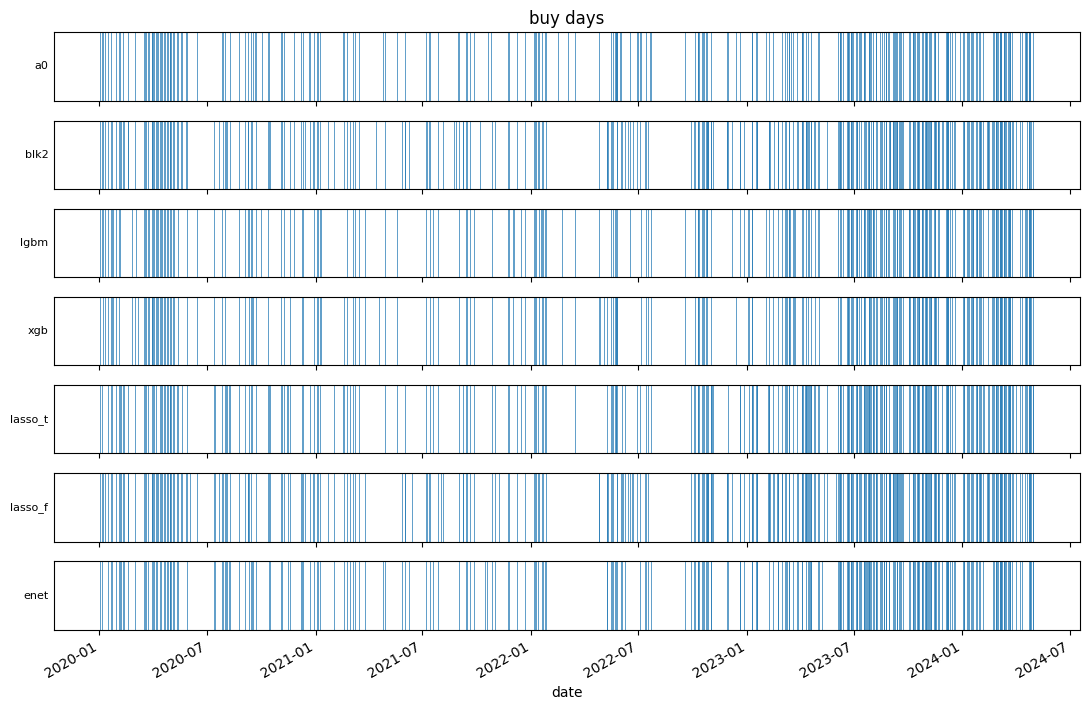

In [16]:
buy = {}
for tag in MODEL_ORDER:
    px = books[tag].loc[common]
    buy[tag] = (px["pos"] > 0)
diag_rows = []
for tag in MODEL_ORDER:
    b = buy[tag]
    px = books[tag].loc[common]
    diag_rows.append({
        "model": LABEL[tag],
        "n_buy": int(b.sum()),
        "pct_buy": 100.0 * float(b.mean()),
        "mean_R|buy": float(px.loc[b, "R"].mean()) if b.any() else float("nan"),
        "mean_R|sell": float(px.loc[~b, "R"].mean()),
        "median_|s|_buy": float(px.loc[b, "signal"].abs().median()) if b.any() else float("nan"),
    })
print(pd.DataFrame(diag_rows).to_string(index=False))
print("always-short n_buy = 0.")

jacc = pd.DataFrame(index=MODEL_ORDER, columns=MODEL_ORDER, dtype=float)
for a in MODEL_ORDER:
    for b in MODEL_ORDER:
        u = buy[a] | buy[b]
        jacc.loc[a, b] = float((buy[a] & buy[b]).sum() / u.sum()) if u.any() else 1.0
jacc.index = [LABEL[t] for t in MODEL_ORDER]
jacc.columns = jacc.index
print("Jaccard of buy-day sets")
print(jacc.round(3).to_string())
jacc.to_csv(OUT / "buy_signal_agreement.csv")
off = jacc.values[np.triu_indices(len(jacc), 1)]
print(f"mean pairwise Jaccard {float(off.mean()):.3f}")

idx = pd.DatetimeIndex(common)
fig, axes = plt.subplots(len(MODEL_ORDER), 1, figsize=(11, 7.2), sharex=True)
for ax, tag in zip(axes, MODEL_ORDER):
    days = idx[buy[tag].to_numpy()]
    ax.vlines(days, 0, 1, color="C0", lw=0.5)
    ax.set_yticks([])
    ax.set_ylabel(tag, rotation=0, ha="right", va="center", fontsize=8)
    ax.set_ylim(0, 1)
axes[-1].set_xlabel("date")
axes[0].set_title("buy days")
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(OUT / "buy_signal_diag_blk2.png", dpi=120, bbox_inches="tight")
print("saved", OUT / "buy_signal_diag_blk2.png")
display(fig)
plt.close(fig)


## 16. Iron condors (straddle + wings / strangle + wings)

Body is the existing nearest-OTM package. Wings are the nearest live
mids at least $25$ (and $50$) points further OTM. Short iron condor =
short body + long wings. Defined-risk long-package return is
$R_{\mathrm{long,ic}}=(\mathrm{exit}_{ic}-\mathrm{entry}_{ic})/\mathrm{width}$,
so the paper's $q$ rules apply unchanged. Credit-denominator $R$ is
printed as a warning only — net credit can be tiny.

width 25.0: days with both wings 1291 / body 1291 dropped 0
width 25.0 credit-denom warning: frac entry_ic<=0 = 0.08%
--- iron condor width 25.0, defined-risk R, blk2 ---
always short
n             871.000000
mean            0.001076
std             0.237364
min            -0.873000
25%            -0.113698
50%             0.059402
75%             0.149098
max             0.595000
skew           -0.822434
ex_kurt         0.851373
t_mean          0.133792
Sharpe_ann      0.071965
n_buy           0.000000
pct_buy         0.000000
long-short volatility
n             871.000000
mean            0.016519
std             0.236790
min            -0.807000
25%            -0.116604
50%             0.030799
75%             0.161300
max             0.873000
skew           -0.141221
ex_kurt         0.884094
t_mean          2.058810
Sharpe_ann      1.107408
n_buy         339.000000
pct_buy        38.920781


width 50.0: days with both wings 1291 / body 1291 dropped 0
width 50.0 credit-denom warning: frac entry_ic<=0 = 0.08%
--- iron condor width 50.0, defined-risk R, blk2 ---
always short
n             871.000000
mean            0.000978
std             0.140941
min            -0.731000
25%            -0.049451
50%             0.033202
75%             0.078300
max             0.398303
skew           -1.396299
ex_kurt         4.007362
t_mean          0.204774
Sharpe_ann      0.110145
n_buy           0.000000
pct_buy         0.000000
long-short volatility
n             871.000000
mean            0.008416
std             0.140692
min            -0.731000
25%            -0.058650
50%             0.015802
75%             0.082050
max             0.714000
skew           -0.370074
ex_kurt         4.085472
t_mean          1.765511
Sharpe_ann      0.949646
n_buy         339.000000
pct_buy        38.920781


saved C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530\iron_condor_vs_straddle_cum.png


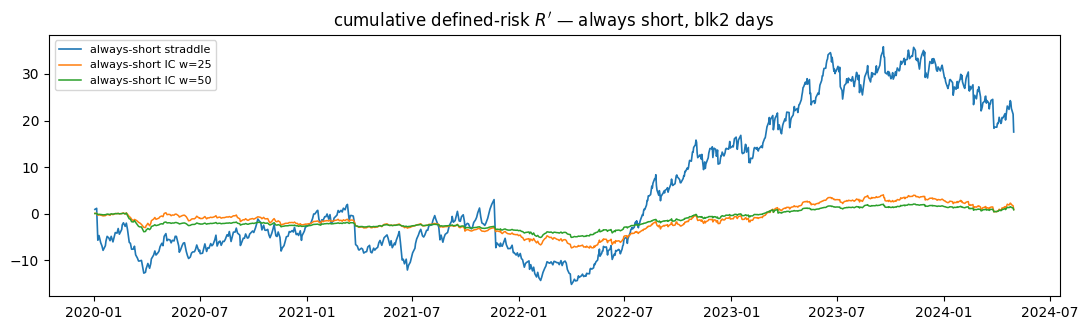

In [17]:
live1530 = book_chain[(book_chain["hhmm"] == "15:30") & np.isfinite(book_chain["mid"]) & (book_chain["mid"] > 0)].copy()
body = atm.reset_index()
close_map = pd.Series(atm["S_close"].to_numpy(), index=pd.to_datetime(atm["expiration"]).values)
close_map.index = pd.to_datetime(close_map.index).tz_localize(None).normalize()

def score_condor(width: float):
    ic = asl.pick_wings(live1530, body, width=width)
    print(f"width {width}: days with both wings {len(ic)} / body {len(body)} dropped {len(body)-len(ic)}")
    ic = asl.settle_package(ic, close_map)
    ic = ic[np.isfinite(ic["entry_ic"]) & np.isfinite(ic["exit_ic"]) & (ic["width"] > 0)].copy()
    ic["R_long_ic"] = (ic["exit_ic"] - ic["entry_ic"]) / ic["width"]
    ic["R_credit"] = np.where(ic["entry_ic"] > 0, ic["exit_ic"] / ic["entry_ic"] - 1.0, np.nan)
    if "day" in ic.columns:
        ic = ic.set_index("day")
    elif "et_c" in ic.columns:
        ic["day"] = pd.to_datetime(ic["et_c"]).dt.tz_convert("America/New_York").dt.normalize().dt.tz_localize(None)
        ic = ic.set_index("day")
    return ic

ic_tabs = {}
for w in (25.0, 50.0):
    ic = score_condor(w)
    ic_tabs[w] = ic
    print(f"width {w} credit-denom warning: frac entry_ic<=0 = {float((ic['entry_ic']<=0).mean()):.2%}")
    for tag in MODEL_ORDER:
        px = books[tag]
        joined = ic.join(px[["signal", "pos", "R"]], how="inner", rsuffix="_strad")
        sizes = asl.rule_sizes(joined)
        common_ic = joined.index.intersection(common)
        tab = pd.DataFrame({
            name: asl.rule_row((sizes[name] * joined["R_long_ic"]).loc[common_ic], sizes[name].loc[common_ic])
            for name in order
        }).T
        safe = f"iron_condor_w{int(w)}_rule_by_strategy_" + "".join(ch if ch.isalnum() else "_" for ch in tag)
        tab.to_csv(OUT / f"{safe}.csv")
    # one strategy-grouped print on blk2
    joined = ic.join(books["blk2"][["signal", "pos", "R"]], how="inner", rsuffix="_strad")
    sizes = asl.rule_sizes(joined)
    common_ic = joined.index.intersection(common)
    print(f"--- iron condor width {w}, defined-risk R, blk2 ---")
    for name in order:
        print(name)
        print(asl.rule_row((sizes[name] * joined["R_long_ic"]).loc[common_ic], sizes[name].loc[common_ic]).to_string())

fig, ax = plt.subplots(figsize=(11, 3.4))
rp_s = (-books["blk2"]["R"]).loc[common].cumsum()
ax.plot(rp_s.index, rp_s.values, label="always-short straddle", lw=1.2)
for w, ic in ic_tabs.items():
    joined = ic.join(books["blk2"][["signal"]], how="inner")
    idx = joined.index.intersection(common)
    ax.plot(idx, (-joined.loc[idx, "R_long_ic"]).cumsum().values, label=f"always-short IC w={int(w)}", lw=1.1)
ax.set_title("cumulative defined-risk $R'$ — always short, blk2 days")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUT / "iron_condor_vs_straddle_cum.png", dpi=120, bbox_inches="tight")
print("saved", OUT / "iron_condor_vs_straddle_cum.png")
display(fig)
plt.close(fig)


## 17. Hand-check one row

- `K_c >= S` and `K_p <= S` at 15:30.
- `entry` = 15:30 `mid_c + mid_p`.
- `exit` = `max(S_close - K_c, 0) + max(K_p - S_close, 0)` with `S_close` from yfinance `^GSPC`.
- `R` = `exit/entry - 1`.
- `yhat` is $\widehat{\sqrt{RV/B}}$ (fit scale). `rv_hat=(m^2+s2)*B` is
  30-min variance.
- Quoted IV is hourly; `iv_30 = iv_hourly / sqrt(2)`, `iv_var = iv_30**2`.
- `signal = rv_hat - iv_var`. $\mathrm{VRP}=-s$. Long-short volatility `pos` is
  $+1$ if signal $> 0$, else $-1$.